In [1]:
import import_ipynb
%run utils.ipynb


2025-01-05 13:43:45.741736: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-05 13:43:45.742730: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-05 13:43:45.745774: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-05 13:43:45.753637: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736052225.766535    2422 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736052225.77

In [2]:
# Load the datasets
folder_path = "./CICIDS_2017/"
train_data, val_data, test_data = load_and_explore_datasets(folder_path)


Train Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1981520 entries, 0 to 1981519
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytess                  float64
 15  Flow Packetss                float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max               

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import pandas as pd

def preprocess_data(train_data, val_data, test_data):
    le = LabelEncoder()
    scaler = StandardScaler()

    # Extract the 'Label' column for each dataset
    train_labels = train_data['Label']
    val_labels = val_data['Label']
    test_labels = test_data['Label']

    # Print unique labels before encoding
    print("Unique labels in train data:", train_labels.unique())
    print("Unique labels in validation data:", val_labels.unique())
    print("Unique labels in test data:", test_labels.unique())

    print("\nFitting LabelEncoder on training labels...")
    le.fit(train_labels)  # Fit on train data only
    print("Classes found by LabelEncoder:", le.classes_)

    # Encode the labels for train, validation, and test datasets
    print("\nEncoding labels for train, validation, and test datasets...")
    train_labels_encoded = le.transform(train_labels)
    val_labels_encoded = le.transform(val_labels)
    test_labels_encoded = le.transform(test_labels)

    # Print the encoded labels for verification
    print("\nEncoded Train Labels (first 10):", train_labels_encoded[:10])
    print("Encoded Validation Labels (first 10):", val_labels_encoded[:10])
    print("Encoded Test Labels (first 10):", test_labels_encoded[:10])

    # Process features for each dataset (train, val, test)
    # --- Train dataset ---
    print("\nProcessing features for the train dataset...")
    train_data.columns = train_data.columns.astype(str)  # Ensure all column names are strings
    train_features = train_data.drop(columns=['Label'])
    train_features_numeric = train_features.select_dtypes(include=['int64'])
    train_features_categorical = train_features.select_dtypes(include=['object'])

    print("Train features (numeric):", train_features_numeric.shape)
    print("Train features (categorical):", train_features_categorical.shape)

    print("\nEncoding categorical features in train data...")
    train_features_categorical_encoded = train_features_categorical.apply(le.fit_transform)
    train_features_combined = pd.concat([train_features_numeric, train_features_categorical_encoded], axis=1)

    print("\nCombined train features (before scaling):\n", train_features_combined.head())

    # Ensure that column names are strings before passing to the scaler
    train_features_combined.columns = train_features_combined.columns.astype(str)

    print("\nScaling train features...")
    train_features_scaled = scaler.fit_transform(train_features_combined)
    print("Scaled train features shape:", train_features_scaled.shape)

    # --- Validation dataset ---
    print("\nProcessing features for the validation dataset...")
    val_data.columns = val_data.columns.astype(str)  # Ensure all column names are strings
    val_features = val_data.drop(columns=['Label'])
    val_features_numeric = val_features.select_dtypes(include=['int64'])
    val_features_categorical = val_features.select_dtypes(include=['object'])

    print("Validation features (numeric):", val_features_numeric.shape)
    print("Validation features (categorical):", val_features_categorical.shape)

    print("\nEncoding categorical features in validation data...")
    val_features_categorical_encoded = val_features_categorical.apply(le.fit_transform)
    val_features_combined = pd.concat([val_features_numeric, val_features_categorical_encoded], axis=1)

    print("\nCombined validation features (before scaling):\n", val_features_combined.head())

    # Ensure that column names are strings before passing to the scaler
    val_features_combined.columns = val_features_combined.columns.astype(str)

    print("\nScaling validation features...")
    val_features_scaled = scaler.transform(val_features_combined)
    print("Scaled validation features shape:", val_features_scaled.shape)

    # --- Test dataset ---
    print("\nProcessing features for the test dataset...")
    test_data.columns = test_data.columns.astype(str)  # Ensure all column names are strings
    test_features = test_data.drop(columns=['Label'])
    test_features_numeric = test_features.select_dtypes(include=['int64'])
    test_features_categorical = test_features.select_dtypes(include=['object'])

    print("Test features (numeric):", test_features_numeric.shape)
    print("Test features (categorical):", test_features_categorical.shape)

    print("\nEncoding categorical features in test data...")
    test_features_categorical_encoded = test_features_categorical.apply(le.fit_transform)
    test_features_combined = pd.concat([test_features_numeric, test_features_categorical_encoded], axis=1)

    print("\nCombined test features (before scaling):\n", test_features_combined.head())

    # Ensure that column names are strings before passing to the scaler
    test_features_combined.columns = test_features_combined.columns.astype(str)

    print("\nScaling test features...")
    test_features_scaled = scaler.transform(test_features_combined)
    print("Scaled test features shape:", test_features_scaled.shape)

    # Prepare final datasets
    X_train = train_features_scaled
    y_train = train_labels_encoded
    X_val = val_features_scaled
    y_val = val_labels_encoded
    X_test = test_features_scaled
    y_test = test_labels_encoded

    print("\nFinal shapes of processed data:")
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    # Get unique labels across all datasets (train, val, test) and store in a list
    labels = list(set(train_labels.unique()).union(val_labels.unique(), test_labels.unique()))

    return X_train, y_train, X_val, y_val, X_test, y_test, le, scaler, labels


In [4]:
X_train, y_train, X_val, y_val, X_test, y_test, le, scaler, labels = preprocess_data(train_data, val_data, test_data)


Unique labels in train data: ['BENIGN' 'DoS Hulk' 'PortScan' 'DDoS' 'DoS GoldenEye' 'Bot' 'FTPPatator'
 'SSHPatator' 'DoS Slowhttptest' 'DoS slowloris' 'Web Attack  Brute Force'
 'Web Attack  XSS' 'Infiltration' 'Web Attack  Sql Injection' 'Heartbleed']
Unique labels in validation data: ['BENIGN' 'DoS Hulk' 'DDoS' 'SSHPatator' 'PortScan' 'DoS GoldenEye'
 'FTPPatator' 'DoS slowloris' 'DoS Slowhttptest' 'Web Attack  XSS' 'Bot'
 'Web Attack  Brute Force' 'Web Attack  Sql Injection' 'Infiltration'
 'Heartbleed']
Unique labels in test data: ['BENIGN' 'DDoS' 'PortScan' 'DoS Hulk' 'SSHPatator' 'FTPPatator'
 'DoS GoldenEye' 'DoS slowloris' 'Web Attack  Brute Force' 'Bot'
 'DoS Slowhttptest' 'Web Attack  XSS' 'Web Attack  Sql Injection'
 'Infiltration' 'Heartbleed']

Fitting LabelEncoder on training labels...
Classes found by LabelEncoder: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTPPatator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSHPatator' 'Web 

/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/utils/extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/utils/extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/utils/extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Scaled train features shape: (1981520, 55)

Processing features for the validation dataset...
Validation features (numeric): (424611, 54)
Validation features (categorical): (424611, 0)

Encoding categorical features in validation data...

Combined validation features (before scaling):
    Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0                53          23637                  2                       2   
1               443             44                  2                       0   
2             59214              3                  2                       0   
3               443              5                  3                       0   
4                80      116542556                  8                       7   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           76                          108   
1                            0                            0   
2                           12       

/tmp/ipykernel_2422/432265042.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=data, palette='Set2')


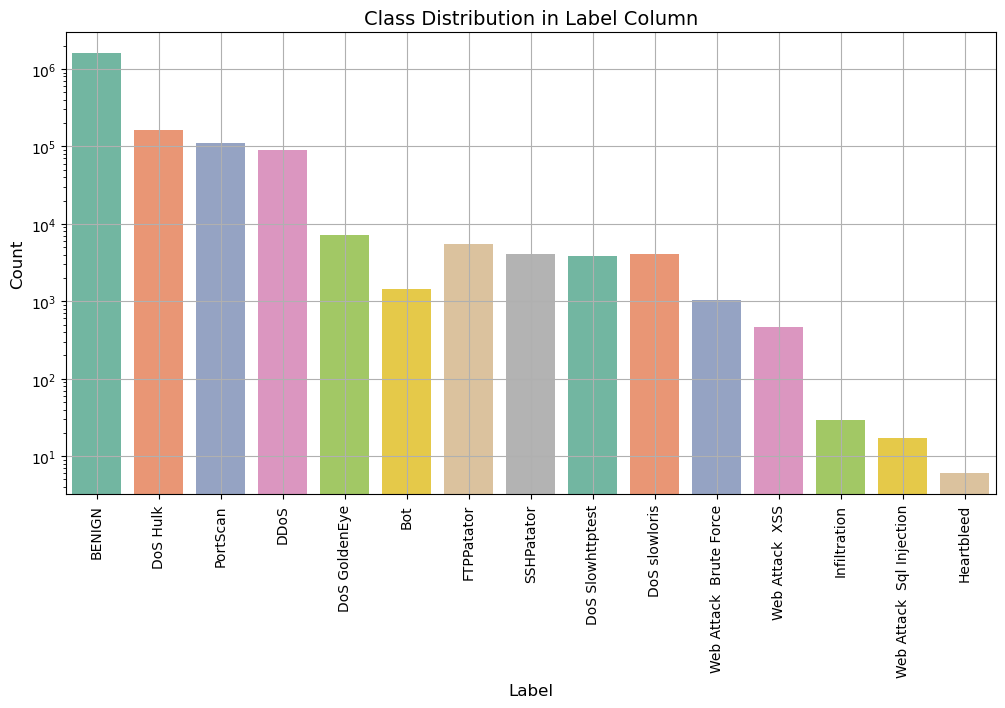

In [5]:
def plot_class_distribution_(data, column='Label'):
    plt.rcParams.update({'font.size': 8})
    plt.figure(figsize=(12, 6))
    sns.countplot(x=column, data=data, palette='Set2')
    plt.title(f"Class Distribution in {column} Column", fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.tick_params(axis='both', labelsize=10)
    plt.yscale('log')
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.show()

plot_class_distribution_(train_data)


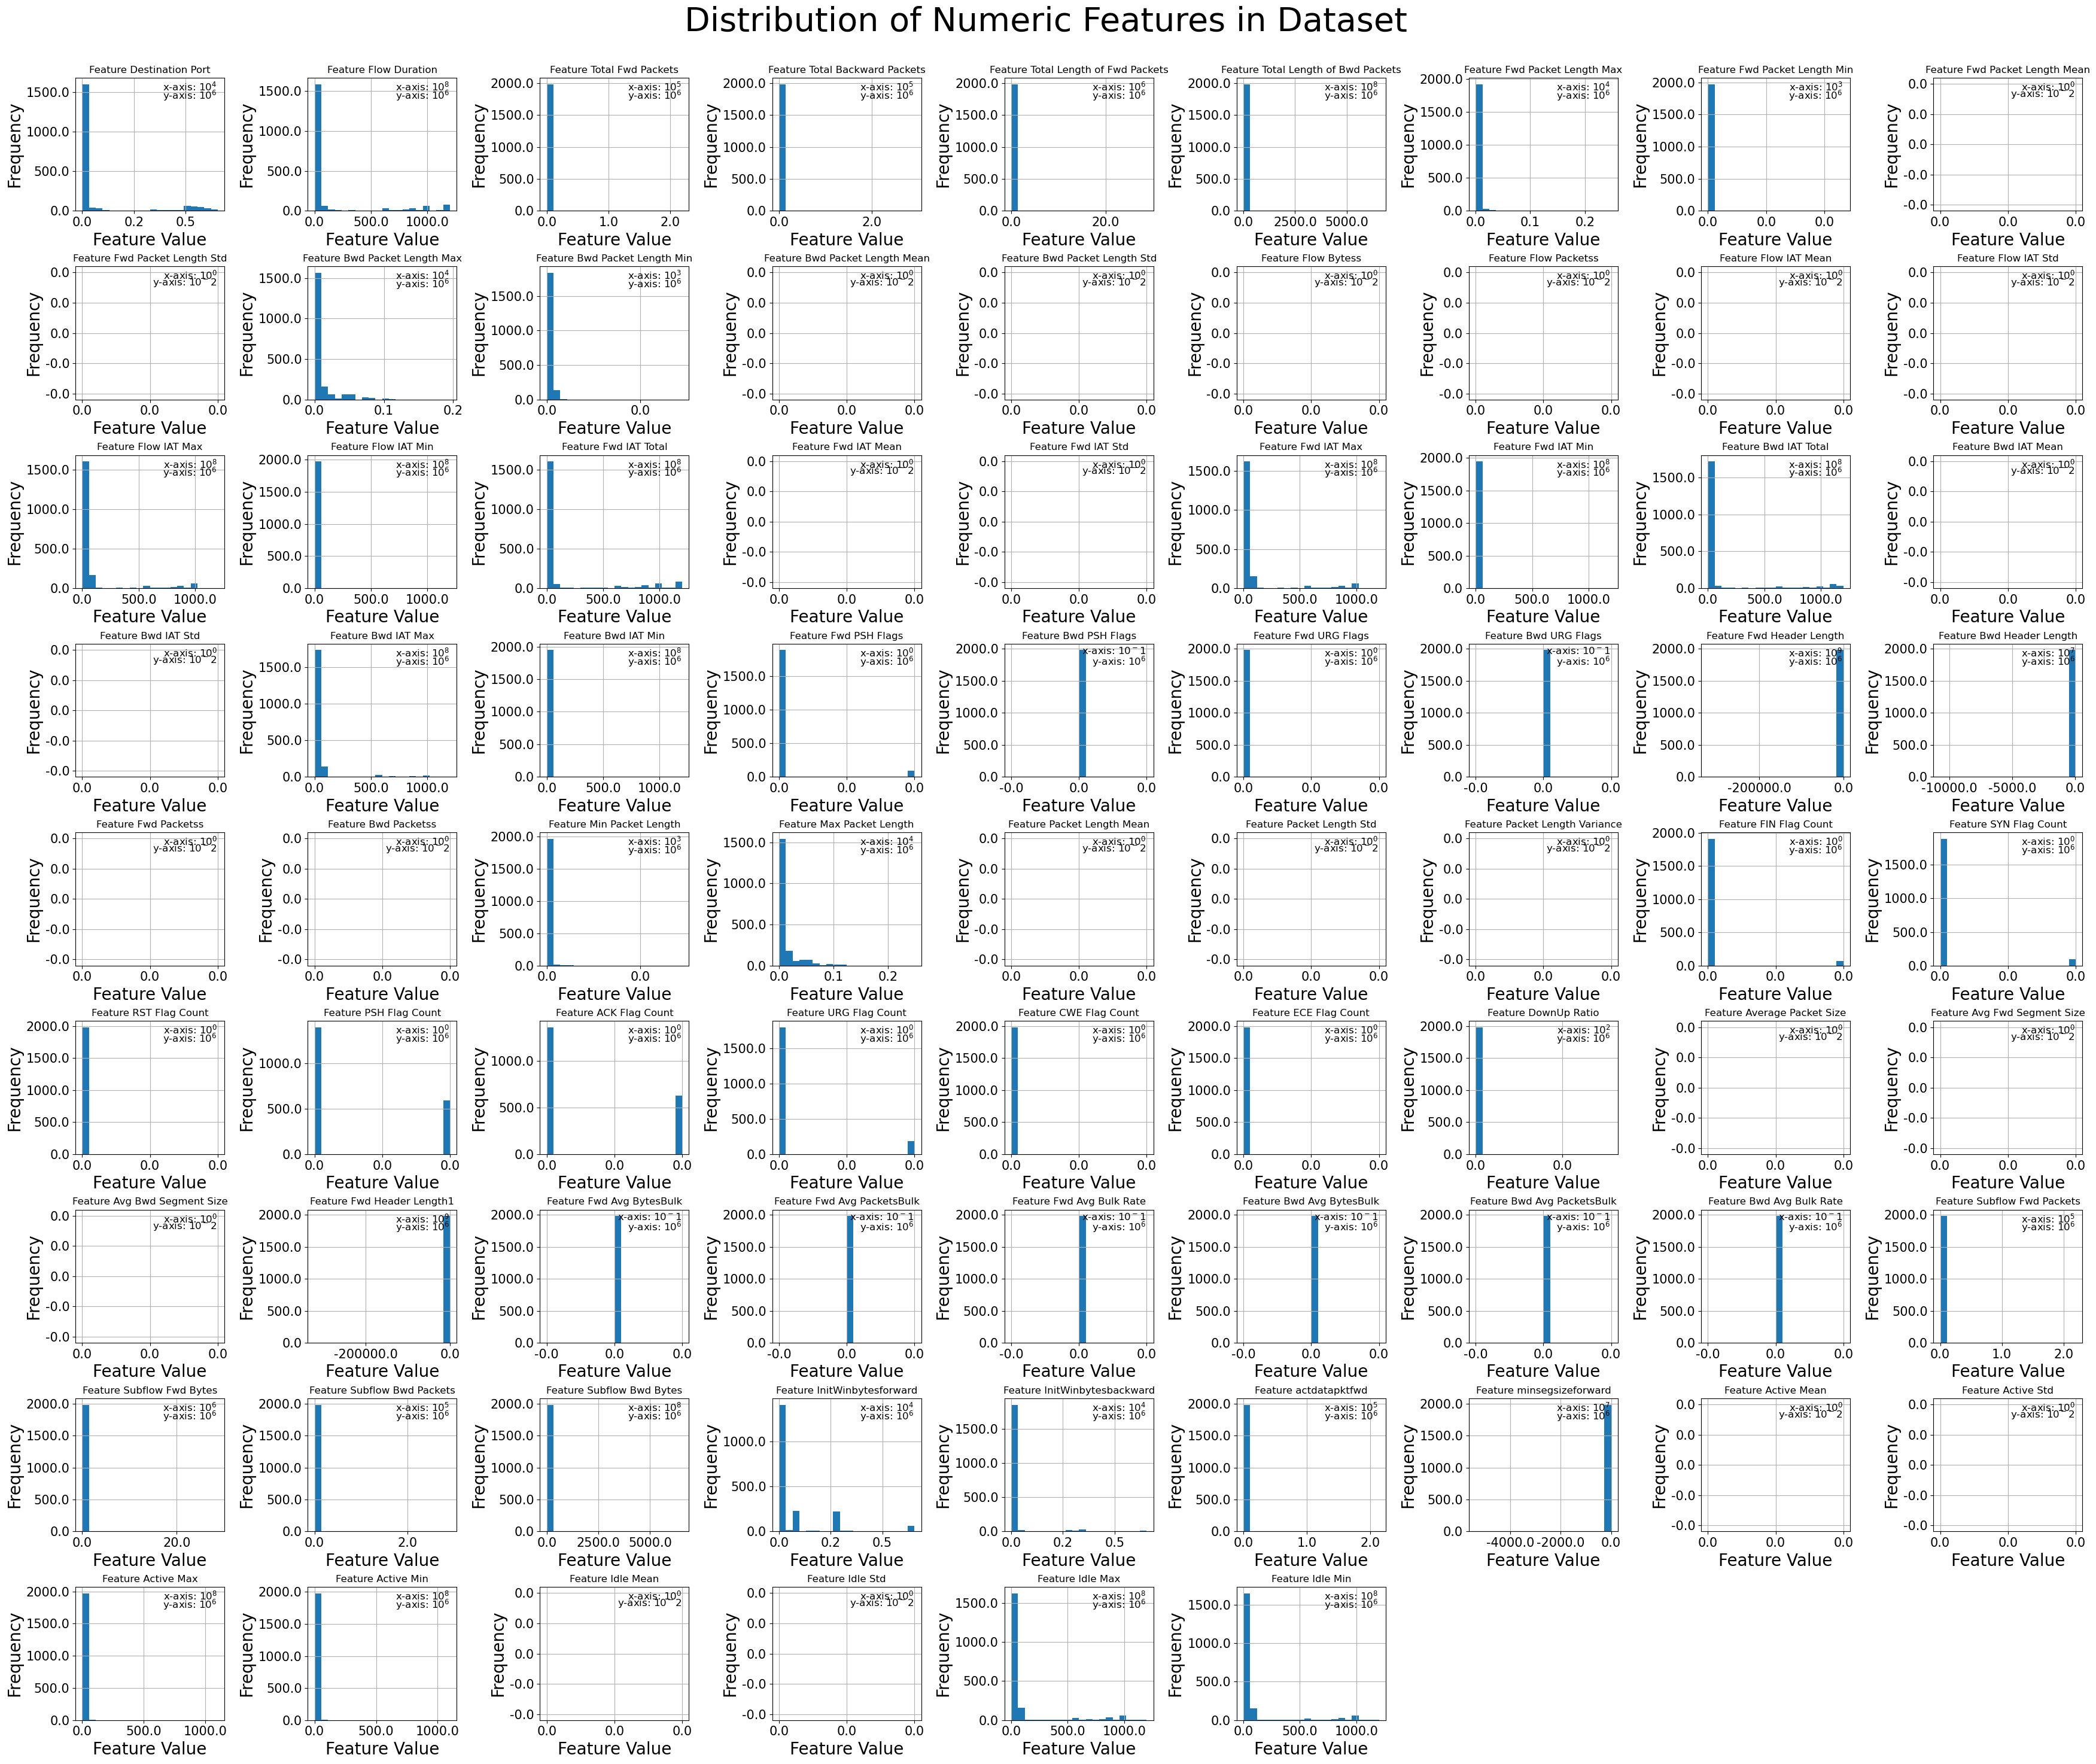

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np

# Formatting functions
def y_axis_formatter(x, pos):
    return f'{x/1000:.1f}'

def x_axis_formatter(x, pos):
    return f'{x/100000:.1f}'

def decimal_formatter(x, pos):
    if x == int(x):
        return f'{int(x)}'
    return f'{x:.2f}'.rstrip('0').rstrip('.')

# Main function to plot numeric feature distribution
def plot_numeric_feature_distribution(data, numeric_features):
    ax = data[numeric_features].hist(bins=20, figsize=(35, 30))
    plt.suptitle("Distribution of Numeric Features in Dataset", fontsize=40)
    numeric_features_list = numeric_features.tolist()

    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            axes = ax[i, j] if ax.ndim > 1 else ax[j]
            feature_index = i * ax.shape[1] + j
            if feature_index < len(numeric_features_list):
                feature_name = numeric_features_list[feature_index]
            else:
                continue
            axes.set_title(f"Feature {feature_name}", fontsize=12)
            axes.tick_params(axis='x', labelsize=15)
            axes.tick_params(axis='y', labelsize=15)
            axes.set_xlabel("Feature Value", fontsize=20)
            axes.set_ylabel("Frequency", fontsize=20)

            axes.xaxis.set_major_formatter(FuncFormatter(x_axis_formatter))
            axes.yaxis.set_major_formatter(FuncFormatter(y_axis_formatter))

            # Adding scientific notation annotations
            x_min, x_max = axes.get_xlim()
            y_min, y_max = axes.get_ylim()

            x_order = int(np.floor(np.log10(x_max)))
            y_order = int(np.floor(np.log10(y_max)))

            axes.text(0.95, 0.98, f'x-axis: $10^{x_order}$', transform=axes.transAxes,
                      fontsize=12, ha='right', va='top', color='black')
            axes.text(0.95, 0.92, f'y-axis: $10^{y_order}$', transform=axes.transAxes,
                      fontsize=12, ha='right', va='top', color='black')

    plt.tight_layout()
    plt.subplots_adjust(top=0.94)
    plt.show()

numeric_features = train_data.select_dtypes(include=['int64', 'float64']).columns
plot_numeric_feature_distribution(train_data, numeric_features)


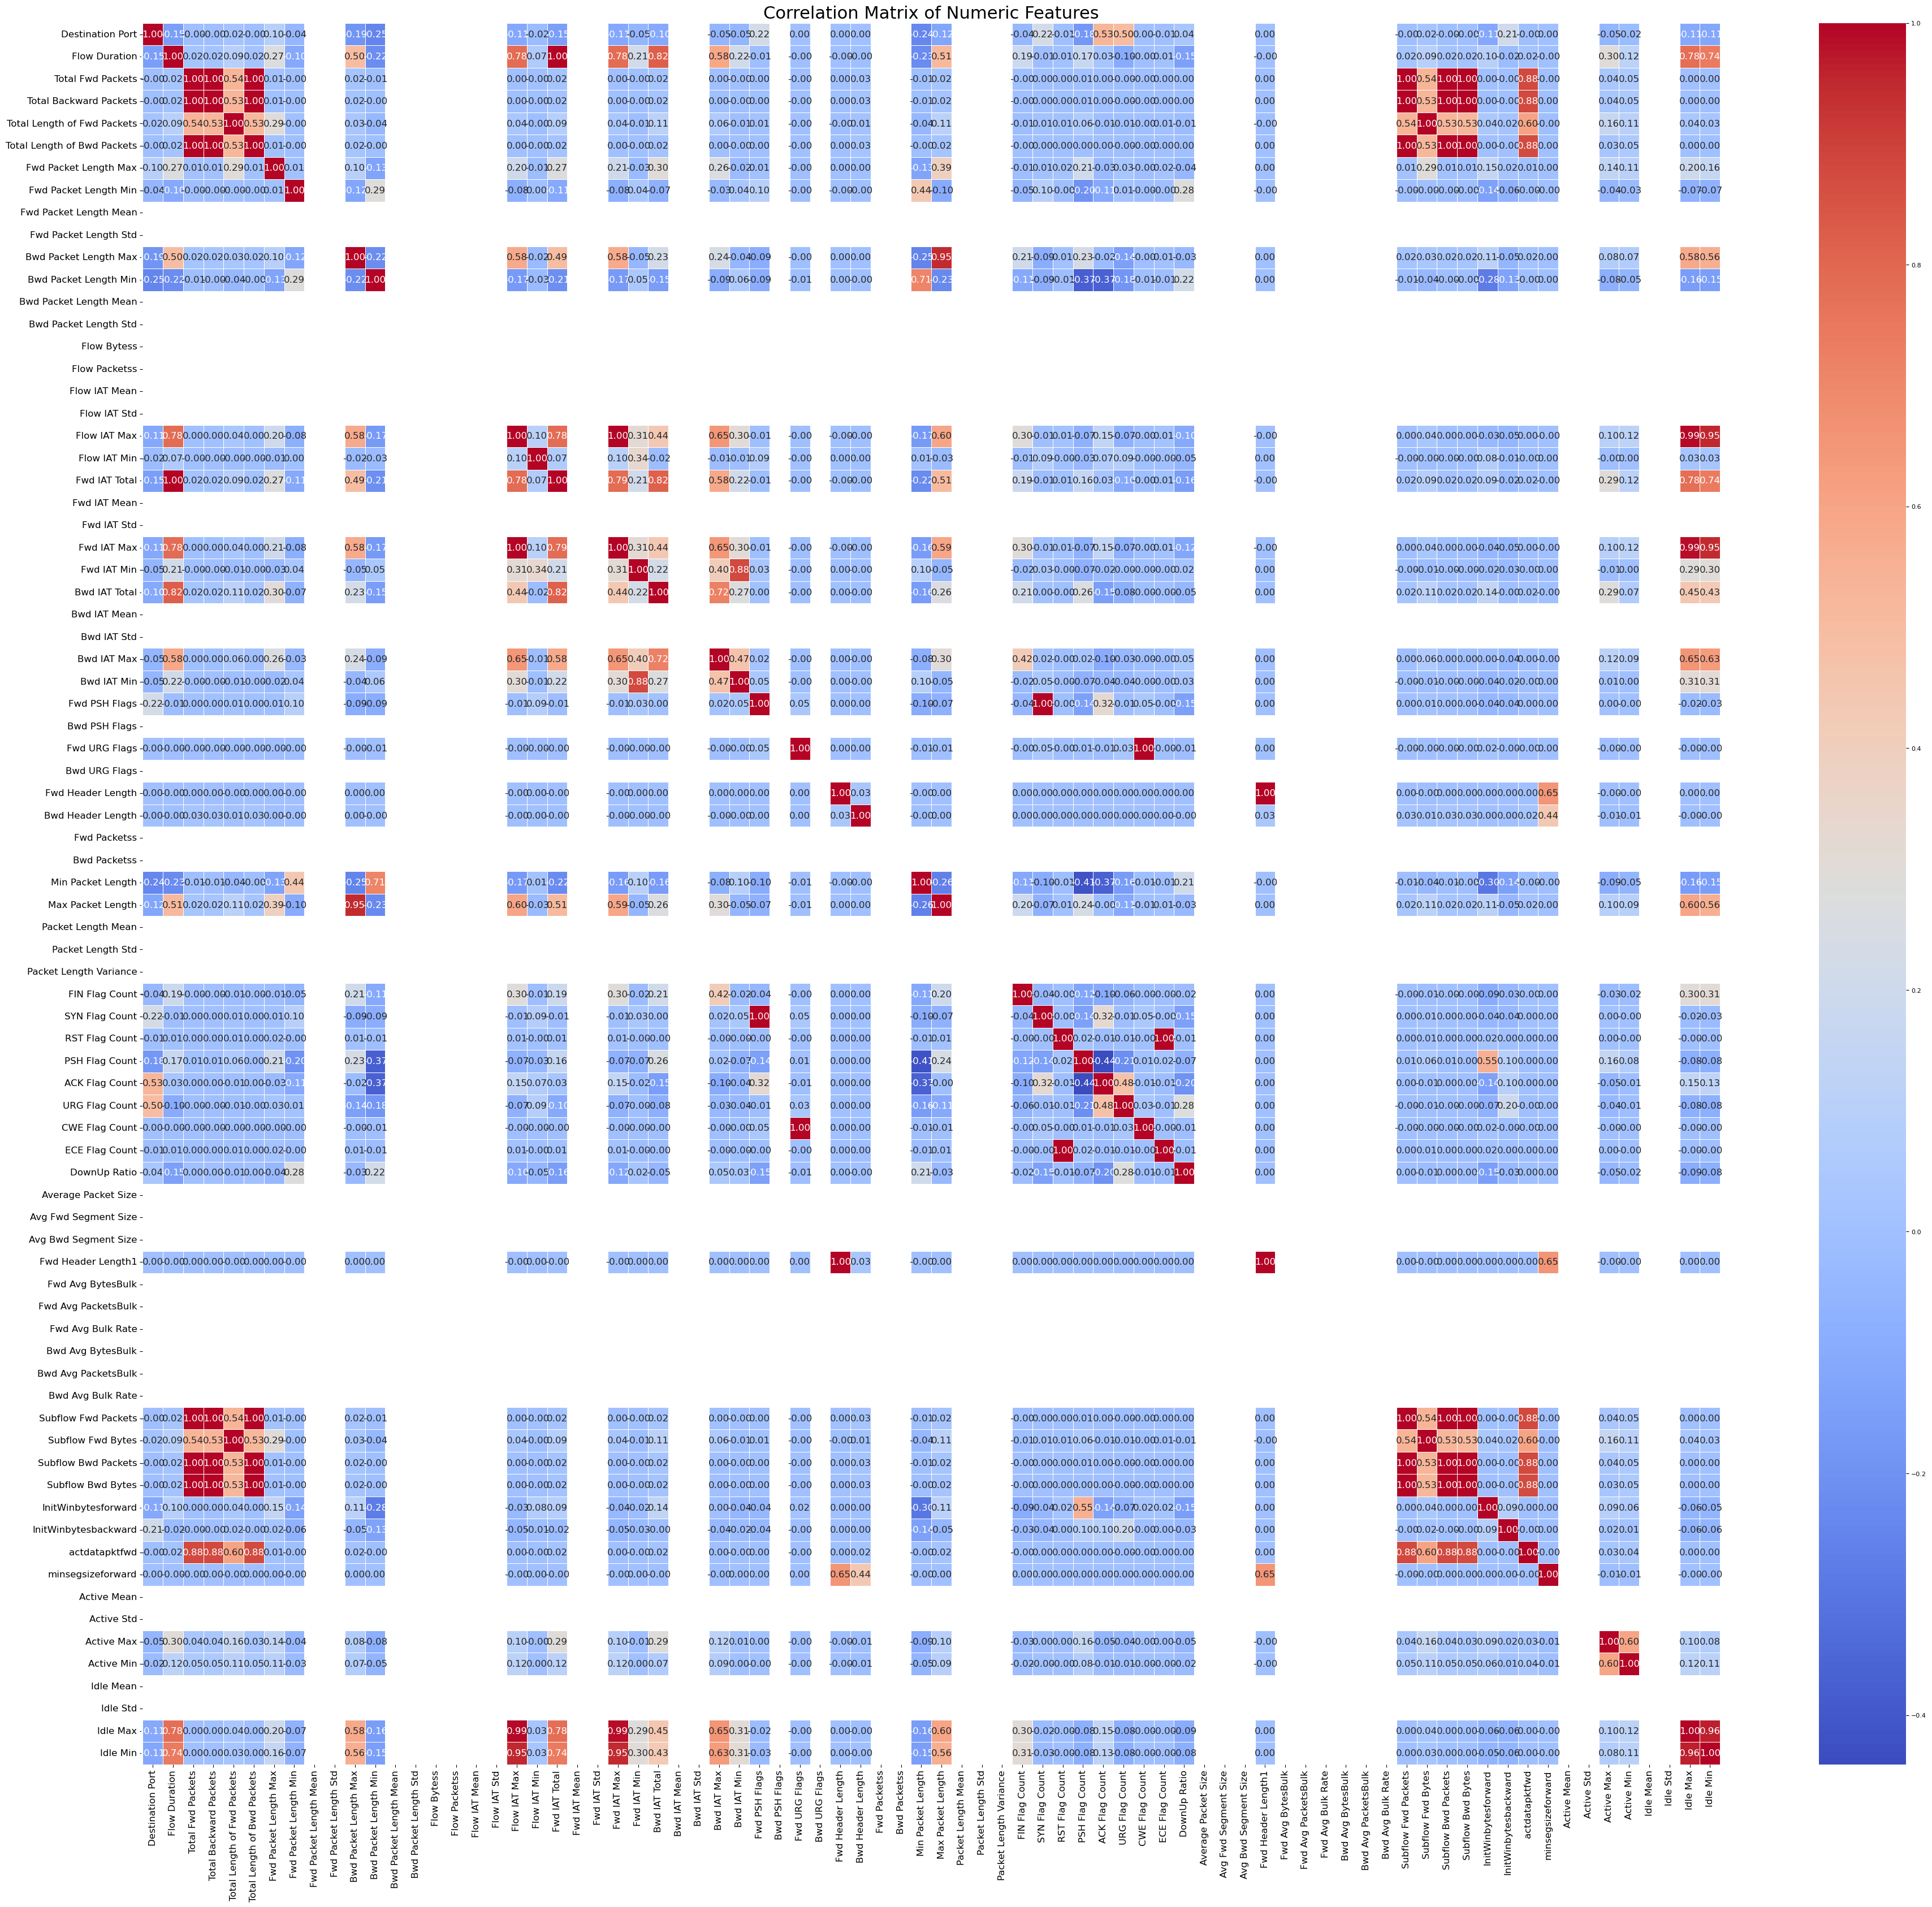

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_matrix(data, numeric_features):
    correlation_matrix = data[numeric_features].corr()
    plt.figure(figsize=(45, 40))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={"size":12})

    plt.tick_params(axis='x', labelsize=12)
    plt.tick_params(axis='y', labelsize=12)
    
    plt.title("Correlation Matrix of Numeric Features", fontsize=22)
    plt.show()

plot_correlation_matrix(train_data, numeric_features)